# COVID-19 Mortality Data: When the Spike Isn’t the Story

COVID-19 mortality data is often treated as if it reflects real-time events. In practice, daily death counts can be shaped by reporting delays, batching, revisions, and aggregation.

This project compares raw daily mortality counts with smoothed trend signals to show why public health data requires domain-aware interpretation.

**Core idea:** The number may be accurate, but the interpretation can still be wrong.

## Data Source

This analysis uses the New York Times public COVID-19 U.S. dataset, which reports cumulative cases and deaths over time. Daily deaths were calculated from cumulative death counts to examine short-term volatility and longer-term mortality trends.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# Load public U.S. COVID-19 time series data from The New York Times

url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us.csv"

df = pd.read_csv(url)

df.head()

,date,cases,deaths
0,2020-01-21,1,0
1,2020-01-22,1,0
2,2020-01-23,1,0
3,2020-01-24,2,0
4,2020-01-25,3,0


In [13]:
df['date'] = pd.to_datetime(df['date'])

# Calculate daily deaths from cumulative death counts
df['daily_deaths'] = df['deaths'].diff()

# Remove the first row because differencing creates one missing value
df = df.dropna()

df.head()

,date,cases,deaths,daily_deaths
1,2020-01-22,1,0,0.0
2,2020-01-23,1,0,0.0
3,2020-01-24,2,0,0.0
4,2020-01-25,3,0,0.0
5,2020-01-26,5,0,0.0


## Raw vs Smoothed Mortality Trends

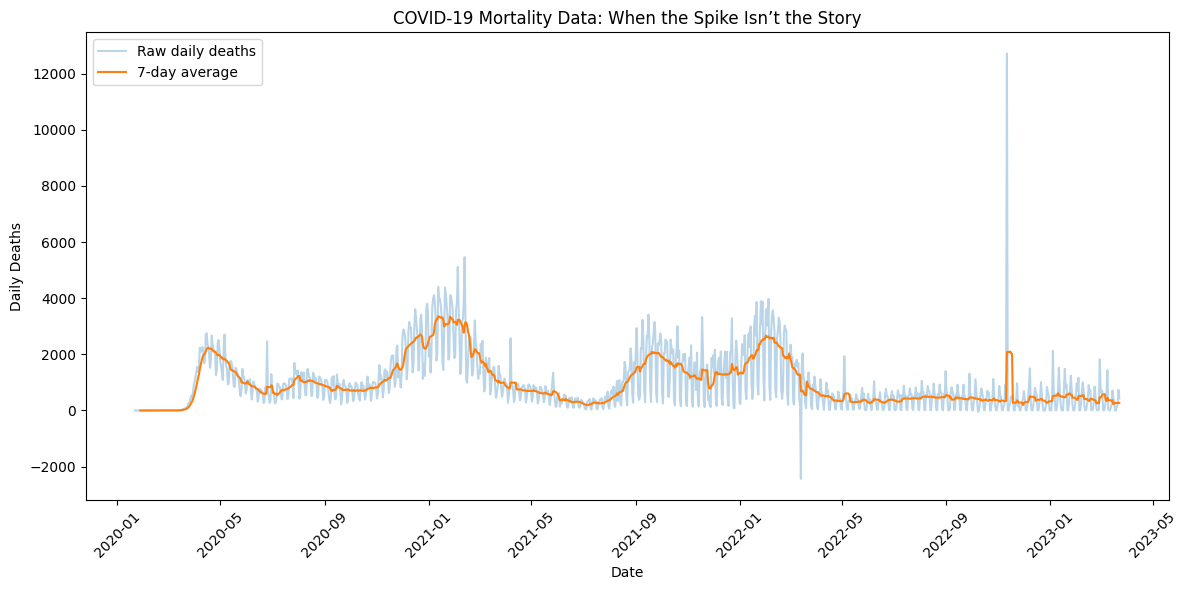

In [14]:
# Create 7-day rolling average
df['deaths_smooth'] = df['daily_deaths'].rolling(7).mean()

plt.figure(figsize=(12, 6))  # make it wider

plt.plot(df['date'], df['daily_deaths'], alpha=0.3, label='Raw daily deaths')
plt.plot(df['date'], df['deaths_smooth'], label='7-day average')

plt.legend()
plt.title("COVID-19 Mortality Data: When the Spike Isn’t the Story")
plt.xlabel("Date")
plt.ylabel("Daily Deaths")

plt.xticks(rotation=45)   # rotate dates
plt.tight_layout()        # prevent overlap

plt.show()

## What This Shows

At first glance, daily COVID-19 death counts appear highly volatile, with sharp spikes and sudden drops.

However, when viewed through a 7-day rolling average, a much clearer trend emerges. The underlying pattern is far more stable than the raw data suggests.

Smoothing does not make the data “true”; it makes the underlying trend easier to evaluate.

## Key Observations

- Daily death counts fluctuate significantly from one day to the next  
- Sudden spikes do not necessarily reflect real-time changes in mortality  
- Reporting delays and data batching can create artificial volatility  

## Takeaway

Daily mortality data can be technically accurate but still misleading when interpreted at face value.

**The number may be accurate, but the interpretation can still be wrong.**

## Limitations

This analysis does not attempt to estimate true infection fatality risk or determine cause-level reporting accuracy. It focuses on how raw daily mortality counts can create misleading visual patterns when interpreted without smoothing or context.